In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn import metrics
import seaborn as sn

In [2]:
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin',
             'bmi', 'pedigree', 'age', 'label']

data = pd.read_csv(
    'diabetes.csv',
    header=None,
    names=col_names
)

print(data.shape)
data.head()

(768, 9)


,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
data.isnull().sum()

pregnant    0
glucose     0
bp          0
skin        0
insulin     0
bmi         0
pedigree    0
age         0
label       0
dtype: int64

In [4]:
feature_cols = ['pregnant', 'insulin', 'bmi',
                'age', 'glucose', 'bp', 'pedigree']

x = data[feature_cols]
y = data.label

In [5]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.3,
    random_state=5
)

display(
    x_train.shape,
    y_train.shape,
    x_test.shape,
    y_test.shape
)

(537, 7)

(537,)

(231, 7)

(231,)

In [6]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [10]:
model = SVC(kernel='rbf', random_state=0)

model.fit(x_train, y_train)

svc_prediction = model.predict(x_test)

print('svc_prediction:', svc_prediction)

svc_prediction: [0 0 0 0 0 0 1 1 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0
 0 0 0 0 0 0 1 0 1 1 0 0 0 1 0 1 0 0 0 0 0 1 0 1 1 1 0 0 0 0 1 1 0 1 0 0 1
 1 0 0 1 1 0 1 1 1 1 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 1 1 0 1 0 0 1 0 0
 1 0 0 0 0 0 1 0 0 1 1 0 0 1 0 0 0 0 0 1 0 1 0 0 0 1 0 1 0 0 1 0 1 0 0 0 0
 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0
 0 1 1 1 0 1 1 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 1 1 0 0 1 0 1 1 0
 1 1 0 0 1 0 0 0 1]


In [11]:
conf_mat = metrics.confusion_matrix(y_test, svc_prediction)

print('SVC [kernel - rbf]')
print('Confusion Matrix:\n', conf_mat)

SVC [kernel - rbf]
Confusion Matrix:
 [[135  25]
 [ 22  49]]


In [12]:
print(classification_report(y_test, svc_prediction))

              precision    recall  f1-score   support

           0       0.86      0.84      0.85       160
           1       0.66      0.69      0.68        71

    accuracy                           0.80       231
   macro avg       0.76      0.77      0.76       231
weighted avg       0.80      0.80      0.80       231



[Text(0.5, 1.0, 'SVC [rbf]')]

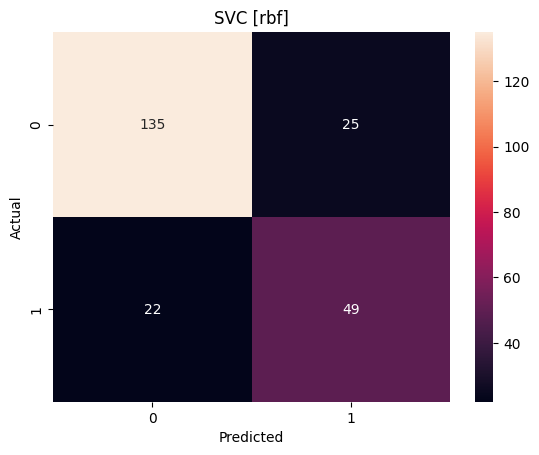

In [13]:
conf_mat = pd.crosstab(
    y_test,
    svc_prediction,
    rownames=['Actual'],
    colnames=['Predicted']
)

sn.heatmap(conf_mat, annot=True, fmt='d').set(
    title='SVC [rbf]'
)

In [14]:
model = SVC(kernel='linear', random_state=0)

model.fit(x_train, y_train)

svc_prediction = model.predict(x_test)

print('svc_prediction:', svc_prediction)

svc_prediction: [0 0 0 0 0 0 1 1 1 0 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0
 0 0 0 0 0 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 0 1 0 1 1 1 0 1 0 0 0 1 0 1 0 0 1
 1 0 0 1 1 0 0 1 1 1 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 1 1 0 1 0 0 1 0 0
 1 0 0 0 0 0 1 0 0 1 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 0 0 0 0
 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 1
 0 1 1 1 0 1 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 1 1 0 0 1 0 1 1 0
 1 1 0 0 0 0 0 0 1]


In [15]:
conf_mat = metrics.confusion_matrix(y_test, svc_prediction)

print('SVC [kernel - linear]')
print('Confusion Matrix:\n', conf_mat)

SVC [kernel - linear]
Confusion Matrix:
 [[136  24]
 [ 23  48]]


In [16]:
Accuracy_score = metrics.accuracy_score(y_test, svc_prediction)

print('Accuracy Score:', Accuracy_score)
print('Accuracy in Percentage:', int(Accuracy_score * 100), '%')

Accuracy Score: 0.7965367965367965
Accuracy in Percentage: 79 %


In [17]:
print(classification_report(y_test, svc_prediction))

              precision    recall  f1-score   support

           0       0.86      0.85      0.85       160
           1       0.67      0.68      0.67        71

    accuracy                           0.80       231
   macro avg       0.76      0.76      0.76       231
weighted avg       0.80      0.80      0.80       231



[Text(0.5, 1.0, 'SVC [linear]')]

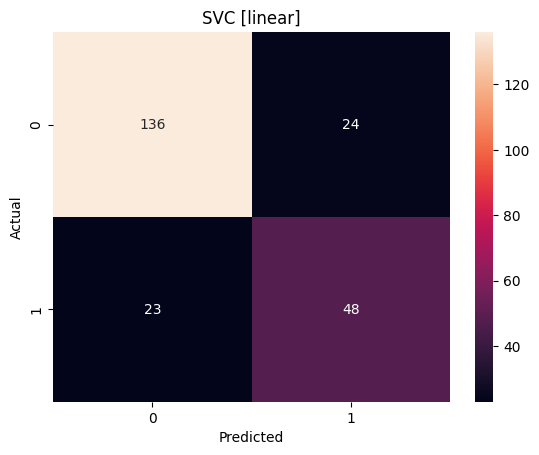

In [18]:
conf_mat = pd.crosstab(
    y_test,
    svc_prediction,
    rownames=['Actual'],
    colnames=['Predicted']
)

sn.heatmap(conf_mat, annot=True, fmt='d').set(
    title='SVC [linear]'
)